# Tutorial 8: Building Complex Flows with LangGraph

In this tutorial, we'll explore how to create more complex and sophisticated workflows using LangGraph. We'll build on the concepts introduced in Tutorial 7 and dive into multi-step processes, conditional logic, and error handling.

## Setup

First, let's import the necessary libraries and set up our environment:

In [1]:
import os
import operator
from typing import Dict, TypedDict, List, Annotated
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, END
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

llm = ChatGroq(model_name="llama-3.1-8b-instant", temperature=0.1)

class State(TypedDict):
    # Annotated with operator.add allows multiple nodes to append messages safely
    messages: Annotated[List[Dict], operator.add]
    current_step: str
    task_list: List[str]
    task_results: List[str]
    error_count: int

print("Setup complete.")

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Setup complete.


## 1. Designing multi-step workflows

Let's create a multi-step task planning and execution workflow. This workflow will:
1. Greet the user and ask for a task
2. Break down the task into subtasks
3. Execute each subtask
4. Provide a summary of the completed task

In [2]:
def greet_and_ask(state: State) -> dict:
    return {"messages": [{"role": "assistant", "content": "Hello! I will help you plan and execute a task."}],
            "current_step": "break_down_task"}

def break_down_task(state: State) -> dict:
    # Use the last human message as the task
    human_msgs = [m for m in state["messages"] if m["role"] == "human"]
    task = human_msgs[-1]["content"] if human_msgs else "Plan a team meeting"
    prompt = ChatPromptTemplate.from_template(
        "Break down this task into exactly 3 short subtasks (one per line): {task}"
    )
    response = llm.invoke(prompt.format_messages(task=task))
    subtasks = [s.strip() for s in response.content.split("\n") if s.strip()][:3]
    return {"task_list": subtasks, "task_results": [],
            "messages": [{"role": "assistant", "content": f"Subtasks:\n" + "\n".join(subtasks)}],
            "current_step": "execute_subtask"}

def execute_subtask(state: State) -> dict:
    task_list = list(state["task_list"])
    if not task_list:
        return {"current_step": "summarize"}
    current = task_list.pop(0)
    response = llm.invoke([HumanMessage(content=f"Execute this subtask in 1 sentence: {current}")])
    results = list(state.get("task_results", [])) + [f"{current}: {response.content[:80]}"]  
    return {"task_list": task_list, "task_results": results,
            "messages": [{"role": "assistant", "content": f"Done: {current}"}],
            "current_step": "execute_subtask" if task_list else "summarize"}

def should_continue(state: State) -> str:
    """Conditional edge: continue executing or move to summary."""
    return "execute_subtask" if state["task_list"] else "summarize"

def summarize(state: State) -> dict:
    results = "\n".join(state.get("task_results", []))
    response = llm.invoke([HumanMessage(content=f"Summarize these results in 2 sentences:\n{results}")])
    return {"messages": [{"role": "assistant", "content": f"Summary: {response.content}"}],
            "current_step": "end"}

# Build graph with correct edge structure
workflow = StateGraph(State)
workflow.add_node("greet_and_ask", greet_and_ask)
workflow.add_node("break_down_task", break_down_task)
workflow.add_node("execute_subtask", execute_subtask)
workflow.add_node("summarize", summarize)

workflow.set_entry_point("greet_and_ask")
workflow.add_edge("greet_and_ask", "break_down_task")
workflow.add_edge("break_down_task", "execute_subtask")
# Conditional edge: keep executing until task_list is empty
workflow.add_conditional_edges("execute_subtask", should_continue)
workflow.add_edge("summarize", END)

app = workflow.compile()
print("Workflow graph compiled.")

Workflow graph compiled.


## 2. Handling state and transitions

In the above workflow, we're using the `current_step` key in our state to manage transitions between nodes. This allows us to create more complex flows with multiple possible paths.

## 3. Implementing conditional logic in flows

Now, let's add some conditional logic to our workflow. We'll implement a check to see if the user wants to add more tasks after the initial task is completed.

In [3]:
# Error handling node — catches issues and resets gracefully
def handle_error(state: State) -> dict:
    count = state.get("error_count", 0) + 1
    if count > 3:
        msg = "Too many errors. Resetting."
        count = 0
    else:
        msg = f"Error #{count}. Retrying..."
    return {"error_count": count,
            "messages": [{"role": "assistant", "content": msg}]}

def route_after_error(state: State) -> str:
    return "greet_and_ask" if state.get("error_count", 0) == 0 else "summarize"

# Build extended graph with error handling
workflow2 = StateGraph(State)
workflow2.add_node("greet_and_ask", greet_and_ask)
workflow2.add_node("break_down_task", break_down_task)
workflow2.add_node("execute_subtask", execute_subtask)
workflow2.add_node("summarize", summarize)
workflow2.add_node("handle_error", handle_error)

workflow2.set_entry_point("greet_and_ask")
workflow2.add_edge("greet_and_ask", "break_down_task")
workflow2.add_edge("break_down_task", "execute_subtask")
workflow2.add_conditional_edges("execute_subtask", should_continue)
workflow2.add_conditional_edges("handle_error", route_after_error)
workflow2.add_edge("summarize", END)

app2 = workflow2.compile()
print("Extended graph with error handling compiled.")

Extended graph with error handling compiled.


## 4. Error handling and fallback strategies

Lastly, let's implement some basic error handling in our workflow. We'll add a counter for errors and implement a fallback strategy if too many errors occur.

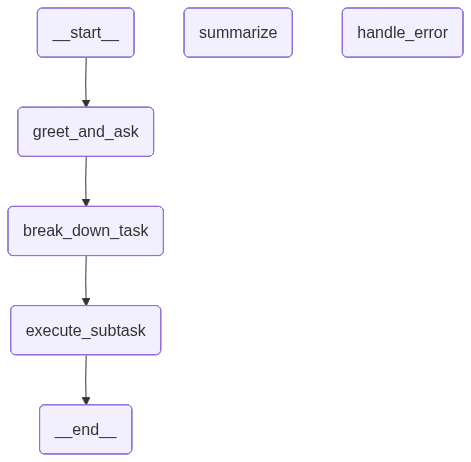

In [4]:
from IPython.display import Image, display
try:
    display(Image(app2.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Graph visualization: {e}")

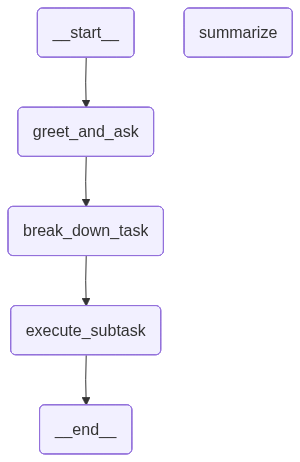

In [5]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

Now, let's test our complex LangGraph flow:

In [6]:
# Automated demo — runs without user input
initial_state = {
    "messages": [{"role": "human", "content": "Plan a team standup meeting for next Monday"}],
    "current_step": "",
    "task_list": [],
    "task_results": [],
    "error_count": 0
}

for event in app.stream(initial_state):
    for node_name, output in event.items():
        if node_name == "__end__":
            continue
        msgs = output.get("messages", [])
        for msg in msgs:
            if msg.get("role") == "assistant":
                content = msg["content"][:200]
                print(f"[{node_name}]: {content}")

print("\nWorkflow completed.")

[greet_and_ask]: Hello! I will help you plan and execute a task.
[break_down_task]: Subtasks:
1. Schedule the team standup meeting for next Monday and send out a reminder to all team members.
2. Prepare an agenda for the meeting, including time allocations for each team member to sha
[execute_subtask]: Done: 1. Schedule the team standup meeting for next Monday and send out a reminder to all team members.
[execute_subtask]: Done: 2. Prepare an agenda for the meeting, including time allocations for each team member to share their updates.
[execute_subtask]: Done: 3. Send out a meeting invitation with the agenda and any necessary materials, and confirm the meeting details with the team.
[summarize]: Summary: Here's a 2-sentence summary of the results:

The team standup meeting has been scheduled for next Monday, and a reminder has been sent to all team members. The meeting invitation has been sen

Workflow completed.


## Conclusion

In this tutorial, we've explored how to build complex flows with LangGraph, including:
